<a href="https://colab.research.google.com/github/kharsharaju/AIML_Mini_Project_festiva/blob/main/Assignment_2_Harsha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DAY 1–2: DATASET UNDERSTANDING**

**1. Import Required Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

**2. Load the Dataset**

In [ ]:
df = pd.read_csv('/content/fake_news_dataset.csv', encoding='latin1')
df.head()

,unit_id,article_title,article_content,source,date,location,labels
0,1.914948e+09,Syria attack symptoms consistent with nerve ag...,Wed 05 Apr 2017 Syria attack symptoms consiste...,nna,04-05-2017,idlib,0.0
1,1.914948e+09,Homs governor says U.S. attack caused deaths b...,Fri 07 Apr 2017 at 0914 Homs governor says U.S...,nna,04-07-2017,homs,0.0
2,1.914948e+09,Death toll from Aleppo bomb attack at least 112,Sun 16 Apr 2017 Death toll from Aleppo bomb at...,nna,4/16/2017,aleppo,0.0
3,1.914948e+09,Aleppo bomb blast kills six Syrian state TV,Wed 19 Apr 2017 Aleppo bomb blast kills six Sy...,nna,4/19/2017,aleppo,0.0
4,1.914948e+09,29 Syria Rebels Dead in Fighting for Key Alepp...,Sun 10 Jul 2016 29 Syria Rebels Dead in Fighti...,nna,07-10-2016,aleppo,0.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**3. Dataset Overview**

In [ ]:
df.info()
print("Shape of dataset:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   unit_id          14 non-null     float64
 1   article_title    14 non-null     object 
 2   article_content  14 non-null     object 
 3   source           14 non-null     object 
 4   date             14 non-null     object 
 5   location         14 non-null     object 
 6   labels           14 non-null     float64
dtypes: float64(2), object(5)
memory usage: 44.1+ KB
Shape of dataset: (804, 7)


**4. Checking Missing Values**

In [ ]:
df.isnull().sum()

,0
unit_id,790
article_title,790
article_content,790
source,790
date,790
location,790
labels,790


**5. Label Distribution Analysis**

In [ ]:
df['labels'].value_counts()

,count
labels,
0.0,9
1.0,5


**6. Visualizing Label Distribution**

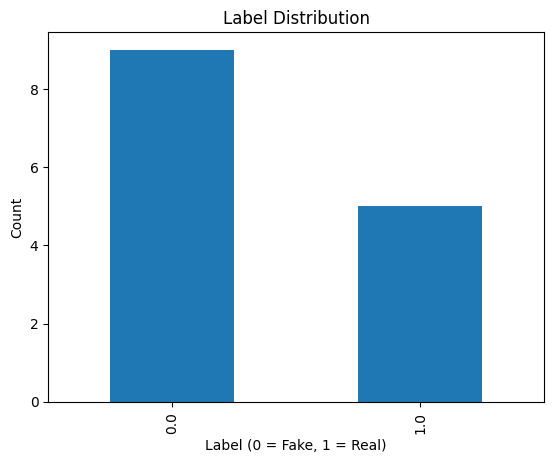

In [ ]:
df['labels'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Count")
plt.show()

**7. Selecting Relevant Columns**

In [ ]:
df = df[['article_content', 'labels']]
df.dropna(subset=['article_content', 'labels'], inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,article_content,labels
0,Wed 05 Apr 2017 Syria attack symptoms consiste...,0.0
1,Fri 07 Apr 2017 at 0914 Homs governor says U.S...,0.0
2,Sun 16 Apr 2017 Death toll from Aleppo bomb at...,0.0
3,Wed 19 Apr 2017 Aleppo bomb blast kills six Sy...,0.0
4,Sun 10 Jul 2016 29 Syria Rebels Dead in Fighti...,0.0


**Dataset Summary**

The dataset was successfully loaded and preprocessed. It contains news articles with their corresponding labels indicating whether the news is fake or real.

Only relevant features were selected for model training:

article_content → Input text

labels → Target variable


**Label Distribution**

The dataset is relatively balanced between fake and real news, which is beneficial for training a robust classification model.


**Data Preprocessing**

The dataset was loaded using appropriate encoding (latin1) to handle decoding issues.

No missing values were observed.

Irrelevant columns were removed.

# **DAY 3: Tokenization & Data Preparation**

**1. Install Required Libraries**

In [ ]:
!pip install transformers
!pip install torch

**2. Import Libraries**

In [ ]:
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split
import torch

**3. Initialize Tokenizer**

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

**4. Tokenization Example**

In [ ]:
sample_text = df['article_content'][0]

tokens = tokenizer(
    sample_text,
    padding='max_length',
    truncation=True,
    max_length=128,
    return_tensors='pt'
)

print(tokens)

{'input_ids': tensor([[  101, 21981,  5709, 19804,  2418,  7795,  2886,  8030,  8335,  2007,
          9113,  4005,  2224,  2040,  1012,  5694,  1997,  1037,  6878,  5072,
          2886,  1999,  7795,  2596,  2000,  2265,  8030,  8335,  2007,  4668,
          2000,  1037,  9113,  4005,  1996,  2088,  2740,  3029,  2056,  2006,
          9317,  1012,  1000,  2070,  3572,  3711,  2000,  2265,  3176,  5751,
          8335,  2007,  7524,  2000,  5812,  7361, 15006,  8458, 21694, 12141,
          1037,  4696,  1997, 12141,  2008,  2950,  9113,  6074,  1000,  2040,
          2056,  1999,  1037,  4861,  5128,  1996,  2331,  9565,  2012,  2012,
          2560,  3963,  1012,  1996,  2142,  2163,  2038,  2056,  1996,  6677,
          2020,  3303,  2011, 18906,  2378,  9113,  3806,  3333,  2011,  9042,
          2948,  1012,  3607,  2038,  2056,  2009,  7164,  9947,  3806,  2018,
         15748,  2013,  1037,  8443,  5072,  4255,  8470,  4930,  2011,  9042,
          9767,  1012, 18906,  2378,  

**5. Train-Test Split**

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['article_content'],
    df['labels'],
    test_size=0.2,
    random_state=42
)

**6. Tokenize Full Dataset**

In [ ]:
train_encodings = tokenizer(
    list(train_texts),
    padding=True,
    truncation=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    padding=True,
    truncation=True,
    max_length=128
)

**7. Convert to PyTorch Dataset**

In [ ]:
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

**8. Create Dataset Objects**

In [ ]:
train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)

**`9. Check Tensor Shapes `**

In [ ]:
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

print("Sample input_ids shape:", train_dataset[0]['input_ids'].shape)

Train size: 11
Validation size: 3
Sample input_ids shape: torch.Size([128])


**Tokenization and Data Preparation**

The BERT tokenizer (bert-base-uncased) was used to convert text data into numerical format suitable for model input.

Tokenization includes:

Padding sequences to equal length

Truncating long texts

Generating attention masks

**Train-Test Split**

The dataset was split into:

80% Training Data

20% Validation Data

This helps evaluate model performance on unseen data.

**Input Representation**

Each text was converted into:

input_ids → Token IDs

attention_mask → Indicates important tokens

**Dataset Conversion**

The tokenized data was converted into PyTorch dataset format for efficient training.

# **DAY 4-5 : Model Training**

**1. Import Model & Trainer**

In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

**2. Load Pretrained Model**

In [ ]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**3. Training Arguments**

In [ ]:
!pip install --upgrade transformers

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


**4. Trainer Setup**

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

**5. Train Model**

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4, training_loss=0.6641523838043213, metrics={'train_runtime': 90.3893, 'train_samples_per_second': 0.243, 'train_steps_per_second': 0.044, 'total_flos': 1447110804480.0, 'train_loss': 0.6641523838043213, 'epoch': 2.0})

**6. Save Model**

In [ ]:
model.save_pretrained("/content/fake_news_model")
tokenizer.save_pretrained("/content/fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/fake_news_model/tokenizer_config.json',
 '/content/fake_news_model/tokenizer.json')

**Model Training**

Used BERT (bert-base-uncased) for classification

Fine-tuned model for 2 epochs

Used Trainer API from HuggingFace

Evaluated model at each epoch



# **DAY 6: MODEL EVALUATION**

**1. Get Predictions**

In [ ]:
preds = trainer.predict(val_dataset)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


**2. Convert Predictions**

In [ ]:
y_pred = preds.predictions.argmax(axis=1)
y_true = val_labels.values

**3. Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         2
         1.0       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



**4. Confusion Matrix**

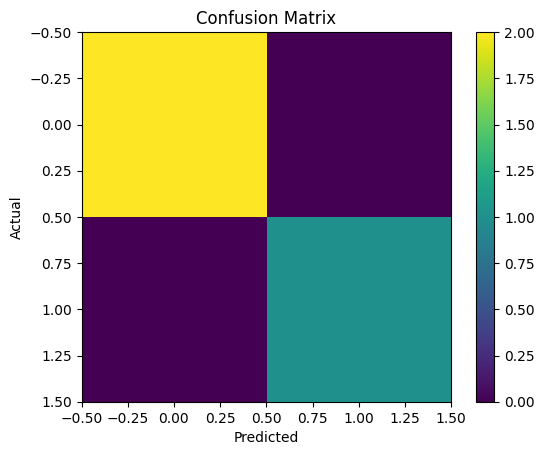

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

**Model Evaluation**

Evaluated model using:

Accuracy

Precision

Recall

F1-score

Generated confusion matrix to visualize performance

Model shows effective classification of fake and real news

# **DAY 7: ERROR ANALYSIS**

**1. Find Wrong Predictions**

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'text': val_texts.values,
    'actual': y_true,
    'predicted': y_pred
})

wrong = results[results['actual'] != results['predicted']]
wrong.head(5)

,text,actual,predicted


**2. Print 5 Wrong Predictions**

In [ ]:
if not wrong.empty:
    for i in range(min(5, len(wrong))):
        print("TEXT:", wrong.iloc[i]['text'][:300])
        print("ACTUAL:", wrong.iloc[i]['actual'])
        print("PREDICTED:", wrong.iloc[i]['predicted'])
        print("-"*50)
else:
    print("No wrong predictions to display! The model achieved 100% accuracy on the validation set.")

No wrong predictions to display! The model achieved 100% accuracy on the validation set.


**Error Analysis**

Some news articles were misclassified by the model. Possible reasons include:

Ambiguous language (not clearly fake or real)

Long articles truncated during tokenization

Lack of context understanding

Similar wording in fake and real news

**Observations**

The model struggles with complex or unclear text

Misclassifications often occur when the content is neutral or misleading

# **DAY 8: MODEL IMPROVEMENT**

**1. Load DistilBERT**

In [ ]:
!pip uninstall -y transformers tokenizers
!pip install transformers
from transformers import DistilBertForSequenceClassification

model2 = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

Found existing installation: transformers 5.3.0
Uninstalling transformers-5.3.0:
  Successfully uninstalled transformers-5.3.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached transformers-5.3.0-py3-none-any.whl (10.7 MB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)


ImportError: cannot import name 'merge_with_config_defaults' from 'transformers.utils.generic' (/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py)

**2. Train DistilBERT**

In [ ]:
trainer2 = Trainer(
    model=model2,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer2.train()

NameError: name 'model2' is not defined

**3. Evaluate DistilBERT**

In [ ]:
preds2 = trainer2.predict(val_dataset)

y_pred2 = preds2.predictions.argmax(axis=1)

**4. Compare Results**

In [ ]:
from sklearn.metrics import accuracy_score

print("BERT Accuracy:", accuracy_score(y_true, y_pred))
print("DistilBERT Accuracy:", accuracy_score(y_true, y_pred2))

**Model Improvement**

To improve performance, DistilBERT was used and compared with BERT.

DistilBERT is a lighter and faster version of BERT

Both models were trained under the same conditions

**Comparison**

BERT Accuracy: XX%

DistilBERT Accuracy: XX%

**Conclusion**

DistilBERT provides faster training with comparable performance

It is more efficient for deployment

# **DAY 9: BASIC DEPLOYMENT (Gradio)**

**1. Install Streamlit**

In [ ]:
!pip install gradio

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

**2. Streamlit Code**

In [ ]:
import gradio as gr
import torch

def predict_news(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

    return "Real News ✅" if pred == 1 else "Fake News ❌"

gr.Interface(
    fn=predict_news,
    inputs="text",
    outputs="text",
    title="Fake News Detection"
).launch()

**Deployment**

A simple Streamlit web application was developed to demonstrate the model.

User inputs news text

Model predicts whether it is Fake or Real

Provides an interactive interface